In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd drive/MyDrive/MaliciousCallDetection/
!cp /content/drive/MyDrive/MaliciousCallDetection/spectrograms_backup.zip /content

!unzip /content/spectrograms_backup.zip -d /content
!mv /content/content/drive/MyDrive/MaliciousCallDetection/dataset/spectrograms /content
!rm -r /content/content

!git config --global user.email "marinescudragos2014@gmail.com"
!git config --global user.name "Marinescu Dragos"


In [ ]:
!pip install -r /content/drive/MyDrive/MaliciousCallDetection/requirements.txt

In [2]:
from tqdm import tqdm
from typing import Optional
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import wandb
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import os
import librosa

In [ ]:
import wandb
wandb.login()

In [ ]:
from collections import Counter
from pathlib import Path

folder = Path("/content/drive/MyDrive/MaliciousCallDetection/dataset/normal")

extensions = Counter(
    p.suffix.lower() or "<no extension>"
    for p in folder.iterdir()
    if p.is_file()
)

extensions

Counter({'.wav': 1648, '.mp3': 40})

In [4]:
#Cleanup
import os
import torch
from tqdm import tqdm
def cleanup():

  base_dir = "/content/drive/MyDrive/MaliciousCallDetection/dataset/spectrograms"
  categories = ["normal", "malicious"]

  corrupt_count = 0
  blank_count = 0

  print("Starting deep clean of spectrograms...")

  for category in categories:
      dir_path = os.path.join(base_dir, category)
      if not os.path.exists(dir_path):
          continue

      files = [f for f in os.listdir(dir_path) if f.endswith('.pt')]

      for f in tqdm(files, desc=f"Cleaning {category}"):
          path = os.path.join(dir_path, f)

          try:
              mel = torch.load(path)
          except Exception as e:
              os.remove(path)
              corrupt_count += 1
              continue  #
          if mel.min().item() == mel.max().item():
              os.remove(path)
              blank_count += 1

  print("\nCleanup Complete!")
  print(f"Successfully deleted {corrupt_count} corrupted files.") #1 corrupted file deleted
  print(f"Successfully deleted {blank_count} blank/silent files.") #83 blank files deleted
#cleanup()


In [5]:
import random
def spectrograms_random_splits(spectogram_path,train_ratio=0.8,val_ratio=0.1):

  normal_sources={}
  malicious_sources={}

  for label, category in enumerate(['normal', 'malicious']):
    dir_path = os.path.join(spectogram_path, category)
    if not os.path.exists(dir_path): continue

    for f in os.listdir(dir_path):
      if f.endswith('.pt'):
        source_name=f"{category}_{f.split('_spectogram_')[0]}"
        full_path=os.path.join(dir_path,f)

        target_dict=normal_sources if label==0 else malicious_sources

        if source_name not in target_dict:
          target_dict[source_name]={'samples': [], 'label': label}

        target_dict[source_name]['samples'].append(full_path)

  def get_split_lists(source_dict):
      source_ids = list(source_dict.keys())
      random.seed(1)
      random.shuffle(source_ids)
      n = len(source_ids)
      train_end = int(n * train_ratio)
      val_end = int(n * (train_ratio + val_ratio))
      train_ids = source_ids[:train_end]
      val_ids = source_ids[train_end:val_end]
      test_ids = source_ids[val_end:]

      return train_ids, val_ids, test_ids

  norm_train, norm_val, norm_test = get_split_lists(normal_sources)
  mal_train, mal_val, mal_test = get_split_lists(malicious_sources)

  def flatten_to_list(ids_list,source_dict):
    flat_list=[]

    for id in ids_list:
      label=source_dict[id]['label']
      for sample in source_dict[id]['samples']:
        flat_list.append((sample,label))
    return flat_list

  train = flatten_to_list(norm_train, normal_sources) + flatten_to_list(mal_train, malicious_sources)
  val   = flatten_to_list(norm_val, normal_sources)   + flatten_to_list(mal_val, malicious_sources)
  test  = flatten_to_list(norm_test, normal_sources)  + flatten_to_list(mal_test, malicious_sources)

  random.shuffle(train)
  random.shuffle(val)
  random.shuffle(test)
  return train, val, test

68842


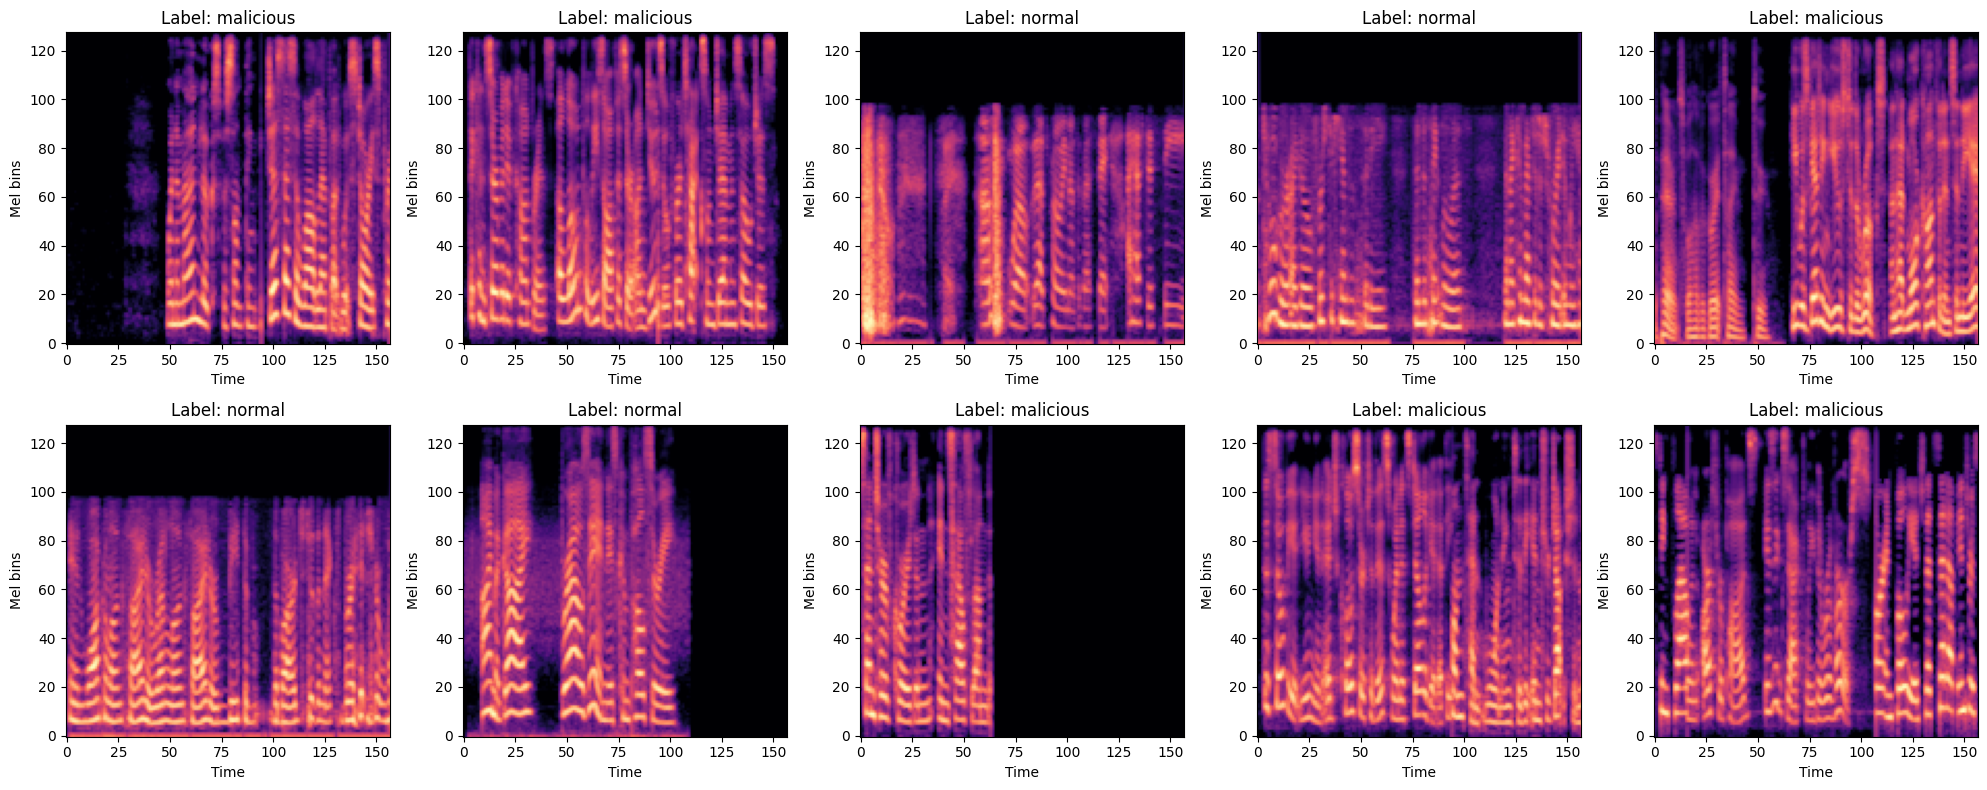

In [6]:
import random
import torchaudio.transforms as T
class Spectrogram(Dataset): #should we add random time shifts? Or LSTM
  def __init__(self,file_list,augment=False):
    self.samples=file_list
    self.augment = augment
    self.time_mask = T.TimeMasking(time_mask_param=20) #vertical black line
    self.freq_mask = T.FrequencyMasking(freq_mask_param=10) # horizontal

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    path,label=self.samples[idx]
    mel_tensor=torch.load(path)

    if self.augment:
      # SpecAugment: randomly mask time and frequency bands
      mel_tensor = self.time_mask(mel_tensor)
      mel_tensor = self.freq_mask(mel_tensor)
      # Add small Gaussian noise
      if torch.rand(1).item() > 0.5:
        mel_tensor = mel_tensor + 0.01 * torch.randn_like(mel_tensor)

    return mel_tensor,label,path

train,val,test=spectrograms_random_splits("/content/spectrograms")
specs = train + test + val
p=Spectrogram(specs,augment=False) #just to check
print(len(p))


fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

random_spectrograms=np.random.choice(len(p), size=10, replace=False)
for idx,spectogram_idx in enumerate(random_spectrograms):
    mel, label,_ = p[spectogram_idx]          # mel: (1, 128, 157)
    mel = mel.squeeze(0)       # (128, 157)

    axes[idx].imshow(
        mel,
        origin='lower',
        aspect='auto',
        cmap='magma'
    )

    axes[idx].set_title(f"Label: {'malicious' if label==1 else 'normal'}")
    axes[idx].set_xlabel("Time")
    axes[idx].set_ylabel("Mel bins")

plt.tight_layout()
plt.show()

In [7]:

def configure_optimizer(model: nn.Module,lr=0.001) -> optim.Optimizer:
    return optim.Adam(model.parameters(), lr)

class CNN(nn.Module):
    def __init__(self,dropout=0.5):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            #we use padding because we don't want to loose pixels from the images margins, now the output matrix is exactly as the input
            #when working with spectrograms this is important
            #formula : out=(W−K+2P)/S ​+ 1
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),#in_channels=1 because spectogram is grayscale not RGB
            nn.BatchNorm2d(32), #Normalization(mean=0,std=1)
            nn.ReLU(),
            nn.MaxPool2d(2),#reduce image in half, concentrating on the most imp pixel

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # This forces the spatial dimensions down to 1x1, regardless of input length.
        self.pool = nn.AdaptiveAvgPool2d((1, 1)) #256 channels, 1 height, 1 width

        # Classification
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), # It's 256 because the last Conv2d output 256 channels
            nn.ReLU(),
            nn.Dropout(0.41), # Added dropout to prevent overfitting
            nn.Linear(256, 2) # 2=num_classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x



In [8]:

class OldCNN(nn.Module):
    def __init__(self):
        super(OldCNN, self).__init__()
        self.features = nn.Sequential(

            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),#in_channels=1 because spectogram is grayscale not RGB
            nn.BatchNorm2d(16), #Normalization(mean=0,std=1)
            nn.ReLU(),
            nn.MaxPool2d(2),#reduce image in half, concentrating on the most imp pixel

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1)) #256 channels, 1 height, 1 width

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x



In [9]:
import torchvision.models as models

class ResNet18(nn.Module):
    def __init__(self, dropout=0.41):
        super(ResNet18, self).__init__()
        self.resnet = models.resnet18(weights=None)
        self.resnet.conv1 = nn.Conv2d( #exactly as the og but with 1 grey channel not 3 RGB
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        num_features = self.resnet.fc.in_features  # 512
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 2)
        )

    def forward(self, x):
        return self.resnet(x)


In [20]:
!git add /content/drive/MyDrive/MaliciousCallDetection/Spectrograms.ipynb
!git commit -m 'Added KFold'
!git push

Auto packing the repository in background for optimum performance.
See "git help gc" for manual housekeeping.
error: cannot lock ref 'refs/remotes/origin/main': Unable to create '/content/drive/MyDrive/MaliciousCallDetection/.git/refs/remotes/origin/main.lock': File exists.

Another git process seems to be running in this repository, e.g.
an editor opened by 'git commit'. Please make sure all processes
are terminated then try again. If it still fails, a git process
may have crashed in this repository earlier:
remove the file manually to continue.
fatal: failed to run reflog
error: task 'gc' failed
[main 370aefb] Added KFold
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 1.48 KiB | 251.00 KiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local ob

In [ ]:
%cd /content/drive/MyDrive/MaliciousCallDetection/dataset/spectrograms/normal
%ls -1 | wc -l
#40877 malicious|
#27965 normal

In [ ]:
%cd /content/spectrograms/normal
%ls -1 | wc -l
#40877 malicious
#27965 normal

In [10]:
def is_silent(audio_segment, sr, top_db=30, min_active_time=2.0):
    """
    Checks if an audio segment is effectively silent.
    top_db: Cuts out every section that is quitere than (Peak - 30 dB)
    min_active_time: Minimum seconds of non-silence required to keep the clip.
    """
    if np.max(np.abs(audio_segment)) < 1e-5: #if whole sound is blank
        return True
    intervals = librosa.effects.split(audio_segment, top_db=top_db)

    if len(intervals) == 0:
        return True

    # Calculate is total duration of non silent aprts is less than 2 sec
    active_samples = sum([end - start for start, end in intervals])
    active_time = active_samples / sr

    return active_time < min_active_time

In [11]:
import os

def save_spectrograms(base_path, output_path, sr=16000, window_size=5.0, min_overlap=1.5):
    window_size_samples = int(window_size * sr)
    min_overlap_samples = int(min_overlap * sr)

    for category in ['normal', 'malicious']:
        os.makedirs(os.path.join(output_path, category), exist_ok=True)

    print(f"Processing data from '{base_path}'...")

    for label, category in enumerate(['normal', 'malicious']):
        dir_path = os.path.join(base_path, category)
        if not os.path.exists(dir_path):
            continue

        valid_files = [f for f in os.listdir(dir_path) if f.lower().endswith(('.wav', '.mp3'))]

        print(f"\nProcessing category: {category.upper()} ({len(valid_files)} files)")

        for f in tqdm(valid_files, desc=f"{category} progress", unit="file"):
            path = os.path.join(dir_path, f)

            try:
                audio_full, _ = librosa.load(path, sr=sr)
                total_samples = len(audio_full)
            except Exception as e:
                print(f"Error loading {f}: {e}. Skipping file.")
                continue

            if total_samples < int(8.5 * sr) and total_samples >= window_size_samples:
                step = max(1, total_samples - window_size_samples)
            else:
                step = window_size_samples - min_overlap_samples

            window_idx = 0
            for start in range(0, total_samples, step):
                save_file_name = f"{os.path.splitext(f)[0]}_spectogram_{window_idx}.pt"
                save_path = os.path.join(output_path, category, save_file_name)

                if os.path.exists(save_path):
                    window_idx += 1
                    continue

                audio_segment = audio_full[start : min(total_samples,start + window_size_samples)]

                if len(audio_segment) < window_size_samples:
                  pad_length = window_size_samples - len(audio_segment)
                  audio_segment = np.pad(audio_segment, (0, pad_length), mode="constant")

                if is_silent(audio_segment, sr): #skip window
                    window_idx += 1
                    continue

                mel_spec = librosa.feature.melspectrogram(y=audio_segment, sr=sr, n_fft=2048,hop_length=512, n_mels=128) #shape=(128,157)
                log_mel = librosa.power_to_db(mel_spec, ref=np.max) #sets the basolute loudest pixel to be 0 and everithing else negative
                log_mel = np.clip(log_mel, -80, 0) #avoid outliers -150 dB = absolute silence
                log_mel = (log_mel - np.mean(log_mel)) / (np.std(log_mel) + 1e-9)
                tensor_mel = torch.tensor(log_mel, dtype=torch.float32).unsqueeze(0) #unsqueeze(0) adds an extra layer at pos 0

                try:
                    torch.save(tensor_mel, save_path)
                except Exception as e:
                    print(f"Error saving spectrogram {save_file_name} from {f}: {e}. Skipping segment.")
                window_idx += 1

    print(f"\nDone! Every spectogram is in '{output_path}'.")

#save_spectrograms("/content/drive/MyDrive/MaliciousCallDetection/dataset","/content/drive/MyDrive/MaliciousCallDetection/dataset/spectrograms")

Model version: 9


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr,▇▆▃▂▁█▇▇▆▅▃▂▂▁▁███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
train/accuracy,▁▅▆▇▇▆▇▇▇▇█████▇▇▇█████████████████
train/loss,█▄▃▂▂▃▂▂▂▂▁▁▁▁▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▃▅▄▇▇▁▁▅▆█▆█▇▇▇▇▇▅▄▆█▇▅▆▇▅█████▇▇▇▇
val/loss,▄▃▄▂▁██▅▂▁▃▁▂▂▂▁▂▄▅▃▁▂▄▃▃▆▁▂▂▁▂▃▃▃▂
epoch,35
lr,0.0
train/accuracy,0.9998
train/loss,0.00097
val/accuracy,0.99225


Normal data=21043, Malicious=32894
Weights applied: Normal=1.28, Malicious=0.82
Starting training on cuda...


Epoch [1/35] | Loss Train: 0.0910 | Loss Validation: 0.0250 | Accuracy: 99.08%
Validation Loss droped. We saved the current model.


Epoch [2/35] | Loss Train: 0.0410 | Loss Validation: 0.0404 | Accuracy: 98.33%


...

Epoch [31/35] | Loss Train: 0.0009 | Loss Validation: 0.0431 | Accuracy: 99.03%


Epoch [32/35] | Loss Train: 0.0010 | Loss Validation: 0.0392 | Accuracy: 99.18%


Epoch [33/35] | Loss Train: 0.0008 | Loss Validation: 0.0348 | Accuracy: 99.31%


Epoch [34/35] | Loss Train: 0.0008 | Loss Validation: 0.0312 | Accuracy: 99.36%


Epoch [35/35] | Loss Train: 0.0008 | Loss Validation: 0.0326 | Accuracy: 99.32%
Done training. Best model saved as: /content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v9_best.pt
Load the model from: /content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v9_best.pt...
Calculating optimal decision threshold using Validation Set

Optimal Threshold Found: 0.5336
Start testing...

 68 (False Negatives):
 - fraud_call87_spectogram_1.pt
 - fraud_call148_spectogram_1.pt
 - fraud_call30_spectogram_3.pt
 - fraud_call155_spectogram_3.pt
 - fraud_call2_spectogram_4.pt
 - fraud_call138_spectogram_2.pt
 - fraud_call2_spectogram_3.pt
 - fraud_call61_spectogram_2.pt
 - Phone Scammer Gets Scammed by Police Captain [jXRHb4sCM8c]_spectogram_55.pt
 - fraud_call138_spectogram_0.pt

        FINAL RESULTS
Accuracy: 98.93%
Precision: 0.9968 How many relevant samples did we get
Recall: 0.9834 How many malicious did we get right
F1-Score: 0.9901 Final Grade


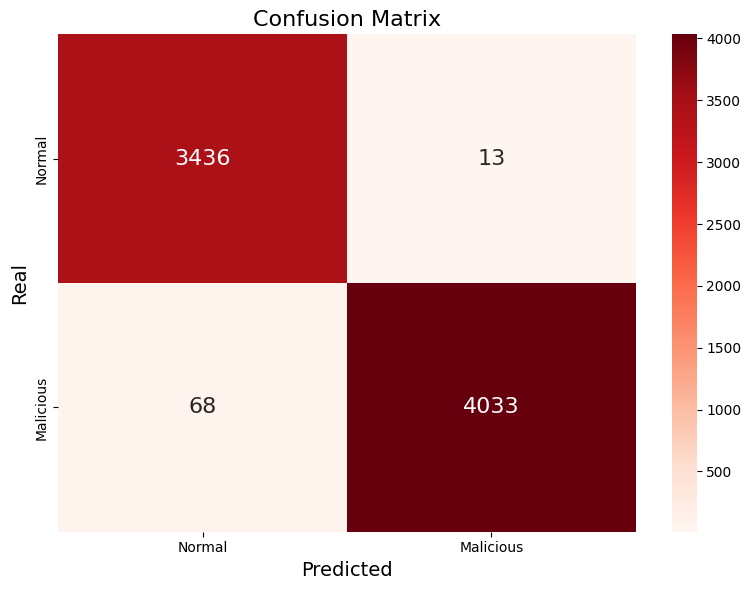

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr,▇▆▃▂▁█▇▇▆▅▃▂▂▁▁███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
train/accuracy,▁▅▆▇▇▆▆▇▇██████▇▇▇█████████████████
train/loss,█▄▃▂▂▃▂▂▂▂▁▁▁▁▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▆▂▆▇▇▇▆▁▇▆▇▆▇▇▇▇▄▂██▇▇▇▇▆▇█▆▆▆▅▆▇▇▇
val/loss,▃▅▂▂▂▁▂█▂▃▂▃▃▃▃▂▆█▂▂▂▂▃▂▅▃▂▅▅▅▆▅▄▄▄
epoch,35
lr,0.0
test/accuracy,98.92715
test/f1,0.99006
test/precision,0.99679


In [29]:
def main(model_version: int,
         lr: float=7.197539212437107e-05,
         epochs: int=35,
         batch_size: int=64):
  data_path='/content/spectrograms'


  train_model(
        path=data_path,
        model_no=model_version,
        lr=lr,
        epochs=epochs,
        bs=batch_size
    )
#implement getting model version from file
if __name__ == "__main__":
  model_version=0
  model_path="/content/drive/MyDrive/MaliciousCallDetection/models"
  for f in os.listdir(model_path):
    if model_version < int(f.split("_v")[1].split("_best")[0]):
      model_version = int(f.split("_v")[1].split("_best")[0])
  model_version+=1
  print(f"Model version: {model_version}")
  main(model_version=model_version)


In [ ]:
!git add /content/drive/MyDrive/MaliciousCallDetection/Spectrograms.ipynb
!git commit -m 'Ran with optuna optimized parameters, modified so we have  a specified threshold for predicting malicious'
!git push

In [21]:
def evaluate_best_model(model_path: str,
                        val_loader:torch.utils.data.DataLoader,
                        test_loader: torch.utils.data.DataLoader,
                        device: torch.device,
                        run: Optional[wandb.sdk.wandb_run.Run]):

  if not os.path.exists(model_path):
    print(f"ERORRE: Nu am găsit niciun model la calea: {model_path}")
    return

  print(f"Load the model from: {model_path}...")

  misclassified_malicious=[]

  if 'v9' in model_path:
    model=ResNet18()
  else:
    model = CNN()
  model.load_state_dict(torch.load(model_path, map_location=device))
  model.to(device)
  model.eval()

  print("Calculating optimal decision threshold using Validation Set\n")

  val_probs=[]
  val_labels=[]

  with torch.no_grad():
    for X_val, y_val,_ in val_loader:
      X_val, y_val = X_val.to(device), y_val.to(device)
      pred=model(X_val)

      probs=torch.softmax(pred,dim=1)[:,1] #take column 1 (probablity of malicious)
      val_probs.extend(probs.cpu().numpy())
      val_labels.extend(y_val.cpu().numpy())

  precisions,recalls,thresholds=precision_recall_curve(val_labels,val_probs)
  f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
  best_idx = np.argmax(f1_scores)
  best_threshold = thresholds[best_idx]
  print(f"Optimal Threshold Found: {best_threshold:.4f}")

  checkpoint = {
    'model_state_dict': model.state_dict(),
    'threshold': float(best_threshold),
    'model_version': 'CNN_v2',
    }

  torch.save(checkpoint, model_path)


  test_preds = []
  test_labels = []

  print("Start testing...")

  with torch.no_grad():
    for X_test, y_test,paths in test_loader:
      X_test = X_test.to(device)
      y_test = y_test.to(device)

      pred = model(X_test)
      probs = torch.softmax(pred, dim=1)[:, 1] #prob of malicious

      predicted = (probs >= best_threshold).long()

      for i in range(len(y_test)):
        if y_test[i] == 1 and predicted[i] == 0:
          file_name = os.path.basename(paths[i])
          misclassified_malicious.append(file_name)

      # GPU->CPU for Scikit-Learn
      test_preds.extend(predicted.cpu().numpy())
      test_labels.extend(y_test.cpu().numpy())

  accuracy = np.mean(np.array(test_preds) == np.array(test_labels)) * 100
  precision = precision_score(test_labels, test_preds, zero_division=0) #How many relevant samples did we get  tp/(tp+fp)
  recall = recall_score(test_labels, test_preds, zero_division=0) #How many malicious did we get right tp/(tp+fn)
  f1 = f1_score(test_labels, test_preds, zero_division=0) #Final grade  2*p*r/(p+r)
  if run:
    run.summary["test/accuracy"] = accuracy
    run.summary["test/precision"] = precision
    run.summary["test/recall"] = recall
    run.summary["test/f1"] = f1

    run.log({"test/confusion_matrix": wandb.plot.confusion_matrix(
            probs=None,
            y_true=test_labels,
            preds=test_preds,
            class_names=['Normal', 'Malicious']
        )})
    print(f"\n {len(misclassified_malicious)} (False Negatives):")
    for name in misclassified_malicious[:10]:
        print(f" - {name}")

    my_table = wandb.Table(columns=["File Name", "Status"])
    for name in misclassified_malicious:
        my_table.add_data(name, "False Negative")
    run.log({"misclassified_files": my_table})


  print("\n" + "="*40)
  print("        FINAL RESULTS")
  print("="*40)
  print(f"Accuracy: {accuracy:.2f}%")
  print(f"Precision: {precision:.4f} How many relevant samples did we get")
  print(f"Recall: {recall:.4f} How many malicious did we get right")
  print(f"F1-Score: {f1:.4f} Final Grade")

  # Confusion Matrix
  cm = confusion_matrix(test_labels, test_preds)

  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
              xticklabels=['Normal', 'Malicious'],
              yticklabels=['Normal', 'Malicious'],
              annot_kws={"size": 16})

  plt.ylabel('Real', fontsize=14)
  plt.xlabel('Predicted', fontsize=14)
  plt.title('Confusion Matrix', fontsize=16)
  plt.tight_layout()
  plt.show()

In [22]:
from sklearn.metrics import precision_recall_curve

def train_model(path: str,
                model_no: int,
                lr: float,
                epochs: int,
                bs: int):


  model = ResNet18()
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model = model.to(device)
  if device.type=="cpu" :
    print("ERROR! Not using GPU")
    return

  train_files,val_files,test_files=spectrograms_random_splits(path)

  count_normal=len([f for f in train_files if f[1]==0])
  count_mal=len([f for f in train_files if f[1]==1])

  total_train = count_normal + count_mal
  w_normal = total_train / (2 * count_normal)
  w_malicious = total_train / (2 * count_mal)

  run=wandb.init(entity="dragosmarinescu19-babes-bolyai-university",
              name=f"run{model_no}",
              project="MaliciousCallDetection",
              config={
                  "lr":lr,
                  "batch_size":bs,
                  "epochs":epochs,
                  "label_smoothing":0.00006,
                  "normal_weights":w_normal,
                  "malicious_weights":w_malicious,
                  "optimizer":"Adam",
                  "model_architecture": "CNN"
               })

  class_weights = torch.tensor([w_normal, w_malicious], dtype=torch.float).to(device)
  print(f"Normal data={count_normal}, Malicious={count_mal}")
  print(f"Weights applied: Normal={w_normal:.2f}, Malicious={w_malicious:.2f}")

  loss_func = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.00006) #added label_smoothing
  optimizer = configure_optimizer(model,run.config.lr)

  #Modified from ReduceLROnPlateau
  scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
      optimizer, T_0=5, T_mult=2, eta_min=1e-6)
  #after 5 epochs lr= maximum, then doubles the nr of epochs, the lr is continuously going down to min

  train_db=Spectrogram(train_files,augment=True)
  val_db=Spectrogram(val_files,augment=False)
  test_db=Spectrogram(test_files,augment=False)

  # before DataLoader train_loader =[1,128,157]
  # after DataLoader train_loader=[32,1,128,157] 32 bathces, 1 channel, height, width
  train_loader = DataLoader(train_db, batch_size=run.config.batch_size, shuffle=True,num_workers=2,pin_memory=True,persistent_workers=True)
  val_loader = DataLoader(val_db, batch_size=run.config.batch_size, shuffle=False,num_workers=2,pin_memory=True,persistent_workers=True)
  test_loader = DataLoader(test_db, batch_size=run.config.batch_size, shuffle=False,num_workers=2,pin_memory=True)

  epochs = run.config.epochs

  best_val_loss = float('inf') # We look after the best score
  best_model_path = f'/content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v{model_no}_best.pt'

  print(f"Starting training on {device}...")

  for epoch in range(epochs):
    model.train() # Put model in training mode
    train_loss = 0.0
    train_correct=0
    train_total=0

    total_batches=len(train_loader)
    batch_loop=tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

    for i, (X_train, y_train,_) in enumerate(batch_loop):
      # Move data to the same device as the model
      X_train = X_train.to(device)
      y_train = y_train.to(device)

      optimizer.zero_grad()
      pred = model(X_train)
      loss = loss_func(pred, y_train)
      loss.backward() #calculate how to fix the error
      optimizer.step() #update the weights

      scheduler.step(epoch + i / total_batches) #we moved it here

      train_loss += loss.item()*X_train.size(0)

      #compare the prediction vector to the y_train vector wich contains labels, then we'll have a boolean tensor
      #after the sum we'll have the number of True elements inside a scalar tensor
      #then we use item() to get the number as a python int
      train_correct+=(pred.argmax(dim=1)==y_train).sum().item()
      train_total+=y_train.size(0)

      current_acc=100 * train_correct / train_total
      current_lr=optimizer.param_groups[0]['lr']
      batch_loop.set_postfix(loss=loss.item(), acc=f"{current_acc:.2f}%", lr=f"{current_lr:.2e}")

    train_acc=train_correct/train_total
    avg_train_loss=train_loss/len(train_loader.dataset)

    # VALIDATION

    model.eval() # STOP the dropout
    val_loss = 0.0
    val_correct=0
    val_total=0

    with torch.no_grad():
      for X_val, y_val,_ in val_loader:
        X_val, y_val = X_val.to(device), y_val.to(device)

        pred = model(X_val)
        loss = loss_func(pred, y_val)
        val_loss += loss.item() * X_val.size(0)

        # Accuracy
        val_correct += (pred.argmax(dim=1) == y_val).sum().item()
        val_total+=y_val.size(0)

    avg_val_loss = val_loss / len(val_loader.dataset)
    current_lr = optimizer.param_groups[0]['lr']

    val_acc = val_correct/val_total
    run.log({"train/loss":avg_train_loss,
             "train/accuracy":train_acc,
             "val/loss":avg_val_loss,
             "val/accuracy":val_acc,
             "lr":current_lr,
             "epoch":epoch+1
             })

    print(f"Epoch [{epoch+1}/{epochs}] | Loss Train: {avg_train_loss:.4f} | Loss Validation: {avg_val_loss:.4f} | Accuracy: {val_acc*100:.2f}%")

    #SAVE
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      torch.save(model.state_dict(), best_model_path)
      print(f"Validation Loss droped. We saved the current model.")

  print(f"Done training. Best model saved as: {best_model_path}")

  evaluate_best_model(best_model_path, val_loader,test_loader, device,run)

  run.finish()


In [32]:
import math
def predict_audio(model_path,file_path,device,model_number,sr=16000, n_mels=128,window_size=5.0,min_overlap=1.5):
  if model_number<6:
    model=OldCNN()
    print("Predicting using OldCNN")
  else:
    if model_number>8:
      model = ResNet18()
      print("Predicting using ResNet18")
    else:
      model = CNN()
      print("Predicting using CNN")

  checkpoint=torch.load(model_path, map_location=device)

  if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
      model.load_state_dict(checkpoint['model_state_dict'])
      threshold = checkpoint.get('threshold', 0.5)
  else:
      model.load_state_dict(checkpoint) # fallback (V6 or lower)
      threshold = 0.5 # fallback threshold

  model.to(device)
  model.eval()


  #START CREATING SPECTROGRAMS
  window_size_samples = int(window_size * sr)
  min_overlap_samples = int(min_overlap * sr)

  try:
    audio, _ = librosa.load(file_path, sr=sr)
    total_samples=len(audio)
    if(total_samples<2.5*sr):
      print("Audio too short for a reliable prediction")
      return
  except Exception as e:
    print(f"Error loading {file_path}: {e}")

  if total_samples < int(8.5 * sr) and total_samples >= window_size_samples:
    step = max(1, total_samples - window_size_samples)
  else:
    step = window_size_samples - min_overlap_samples
  spectrograms=[]

  for start in range(0, total_samples, step):
    audio_segment = audio[start : min(total_samples,start + window_size_samples)]

    if len(audio_segment) < window_size_samples:
      pad_length = window_size_samples - len(audio_segment)
      audio_segment = np.pad(audio_segment, (0, pad_length), mode="constant")

    if is_silent(audio_segment, sr): #skip window
      continue

    mel_spec = librosa.feature.melspectrogram(y=audio_segment, sr=sr, n_fft=2048,hop_length=512, n_mels=128)
    log_mel = librosa.power_to_db(mel_spec, ref=np.max) #shape=(128,157)

    log_mel = np.clip(log_mel, -80, 0)
    log_mel = (log_mel - np.mean(log_mel)) / (np.std(log_mel) + 1e-9)

    tensor_mel = torch.tensor(log_mel,dtype=torch.float32).unsqueeze(0).unsqueeze(0) # shape: [1, 1, n_mels, time]
    spectrograms.append(tensor_mel)

  #DONE CREATING SPECTROGRAMS

  fig, axes = plt.subplots(math.ceil(len(spectrograms)/5), 5, figsize=(20,8))
  axes=axes.flatten()

  malicious_windows_count=0
  with torch.no_grad():
    total_probs=[]
    for idx,x in enumerate(spectrograms):
      x=x.to(device)
      pred = model(x)
      prob=torch.softmax(pred,dim=1) #tensor([[0.31, 0.69]])

      malicious_prob=prob[0][1].item()
      is_malicious=malicious_prob>=threshold
      if is_malicious:
        malicious_windows_count+=1

      total_probs.append(prob.cpu().numpy()[0]) # array([0.31, 0.69], dtype=float32)


      mel = x.squeeze(0).squeeze(0).cpu().numpy()   # (128,157)
      axes[idx].imshow(
          mel,
          origin='lower',
          aspect='auto',
          cmap='magma'
      )

      axes[idx].set_title(f"Predicted {"Malicious" if is_malicious else "Normal"}")
      axes[idx].set_xlabel("Time")
      axes[idx].set_ylabel("Mel bins")
    plt.tight_layout()
    plt.show()

  malicious_ratio=malicious_windows_count/len(spectrograms)
  predicted_class = 1 if malicious_ratio >= 0.5 else 0

  avg_probs=np.mean(total_probs,axis=0)
  confidence=avg_probs[predicted_class]*100

  print(f"Threshold Used: {threshold:.4f}")
  print(f"Malicious Windows: {malicious_windows_count}/{len(spectrograms)} ({malicious_ratio*100:.1f}%)")
  print("Predicted class: Malicious") if predicted_class==1 else print("Predicted class: Normal")
  print(f"Confidence: {confidence:.2f}")


In [ ]:
#import sounddevice as sd for audio recording
from scipy.io.wavfile import write
import os
import librosa
import torch
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path="/content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v8_best.pt"
file_path = "/content/drive/MyDrive/MaliciousCallDetection/records/Sales Call example 1 [4ostqJD3Psc].wav"

model_number=int(model_path.split("_v")[1].split("_best")[0])
print("Model number ",model_number)
predict_audio(model_path,file_path,device,model_number)


Model number  8
Predicting using CNN


In [ ]:
!yt-dlp -f bestaudio --extract-audio --audio-format wav https://www.youtube.com/watch?v=4ostqJD3Psc

In [ ]:
import os

zip_path = "/content/drive/MyDrive/MaliciousCallDetection/dataset/spectrograms"
output_zip_file = "/content/drive/MyDrive/MaliciousCallDetection/spectrograms_backup.zip"

!zip -r "{output_zip_file}" "{zip_path}"
print(f"Folder '{zip_path}' zipped to '{output_zip_file}'")

In [ ]:
import optuna
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True) # Learning rates should always be searched logarithmically
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    dropout = trial.suggest_float("dropout", 0.3, 0.6)
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.2)
    T_0 = trial.suggest_categorical("T_0", [5, 10])

    device = torch.device("cuda")
    model = CNN(dropout=dropout).to(device)

    train_files, val_files, _ = spectrograms_random_splits("/content/spectrograms")

    train_db = Spectrogram(train_files, augment=True)
    val_db = Spectrogram(val_files, augment=False)
    train_loader = DataLoader(train_db, batch_size=batch_size, shuffle=True,num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_db, batch_size=batch_size, shuffle=False,num_workers=2, pin_memory=True)

    count_normal = len([f for f in train_files if f[1] == 0])
    count_mal = len([f for f in train_files if f[1] == 1])
    total_train = count_normal + count_mal
    w_normal = total_train / (2 * count_normal)
    w_malicious = total_train / (2 * count_mal)
    class_weights = torch.tensor([w_normal, w_malicious], dtype=torch.float).to(device)

    loss_func = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=T_0, T_mult=2, eta_min=1e-6)

    # Train for fewer epochs during search (15 is enough to compare configs)
    n_epochs = 15
    best_val_loss = float('inf')

    for epoch in range(n_epochs):
        model.train()
        total_batches = len(train_loader)
        batch_loop=tqdm(train_loader, desc=f"Epoch [{epoch+1}/{n_epochs}]", leave=False)

        for i, (X, y, _) in enumerate(batch_loop):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            loss = loss_func(pred, y)
            loss.backward()
            optimizer.step()
            scheduler.step(epoch + i / total_batches)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                loss = loss_func(pred, y)
                val_loss += loss.item() * X.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)
        best_val_loss = min(best_val_loss, avg_val_loss)

        # Optuna pruning: stop bad trials early
        trial.report(avg_val_loss, epoch)
        if trial.should_prune(): #if loss is really bad compared to other trials then it kills the loop
            raise optuna.exceptions.TrialPruned()

    return best_val_loss
# Run the study
study = optuna.create_study(
    study_name="CNN_Hyperparameter_Tuning_v7",
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5)
)
study.optimize(objective, n_trials=20, timeout=7200)  # 20 trials or 2h max
print("Best trial:")
print(f"  Val Loss: {study.best_trial.value:.4f}")
print(f"  Params: {study.best_trial.params}")

[I 2026-03-23 15:53:27,689] A new study created in memory with name: CNN_Hyperparameter_Tuning_v7
[I 2026-03-23 16:01:17,757] Trial 0 finished with value: 0.05549636215024929 and parameters: {'lr': 0.00011627053149358825, 'batch_size': 64, 'dropout': 0.5987025932174368, 'label_smoothing': 0.008258856896729472, 'T_0': 10}. Best is trial 0 with value: 0.05549636215024929.
[I 2026-03-23 16:09:24,224] Trial 1 finished with value: 0.14136304472869168 and parameters: {'lr': 1.011682999964276e-05, 'batch_size': 32, 'dropout': 0.3793943454949708, 'label_smoothing': 0.04627154230586914, 'T_0': 10}. Best is trial 0 with value: 0.05549636215024929.
[I 2026-03-23 16:17:09,980] Trial 2 finished with value: 0.23891636121859477 and parameters: {'lr': 0.0004923030744681946, 'batch_size': 64, 'dropout': 0.33717933896513264, 'label_smoothing': 0.11282038041987628, 'T_0': 10}. Best is trial 0 with value: 0.05549636215024929.
[I 2026-03-23 16:20:22,027] Trial 3 pruned. 
[I 2026-03-23 16:23:31,854] Trial 4

Best trial:
  Val Loss: 0.0261
  Params: {'lr': 7.197539212437107e-05, 'batch_size': 64, 'dropout': 0.4116196473586018, 'label_smoothing': 6.699445564764539e-05, 'T_0': 5}


In [ ]:
from sklearn.model_selection import KFold

def kfold(spectogram_path, n_folds=5):
  normal_sources = {}
  malicious_sources = {}

  for label, category in enumerate(['normal', 'malicious']):
      dir_path = os.path.join(spectogram_path, category)
      if not os.path.exists(dir_path): continue
      for f in os.listdir(dir_path):
          if f.endswith('.pt'):
              source_name = f"{category}_{f.split('_spectogram_')[0]}"
              full_path = os.path.join(dir_path, f)
              target = normal_sources if label == 0 else malicious_sources
              if source_name not in target:
                  target[source_name] = {'samples': [], 'label': label}
              target[source_name]['samples'].append(full_path)

  def get_folds(source_dict):
      source_ids = sorted(source_dict.keys())
      kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
      return [(
          [source_ids[i] for i in train_idx],
          [source_ids[i] for i in val_idx]
      ) for train_idx, val_idx in kf.split(source_ids)]

  norm_folds = get_folds(normal_sources)
  mal_folds = get_folds(malicious_sources)

  def flatten(ids_list, source_dict):
    flat = []
    for sid in ids_list:
      for sample in source_dict[sid]['samples']:
        flat.append((sample, source_dict[sid]['label']))
    return flat

  all_folds = []
  for i in range(n_folds):
    train = (flatten(norm_folds[i][0], normal_sources) +
              flatten(mal_folds[i][0], malicious_sources))
    val = (flatten(norm_folds[i][1], normal_sources) +
            flatten(mal_folds[i][1], malicious_sources))
    random.shuffle(train)
    random.shuffle(val)
    all_folds.append((train, val))

  return all_folds


In [19]:
def main_kfold_evaluation(data_path="/content/spectrograms", n_folds=5):
    folds = kfold(data_path, n_folds=n_folds)

    config = {
        "n_folds": n_folds,
        "epochs": 35,
        "batch_size": 64,
        "lr": 7.197e-05,
        "model_type": "CNN",
        "label_smoothing": 0.00006
    }
    group_id = f"kfold-session-{wandb.util.generate_id()}"
    rezultate_folduri = []

    for fold_idx, (train_files, val_files) in enumerate(folds):
        run = wandb.init(
            project="MaliciousCallDetection",
            group=group_id,
            name=f"fold_{fold_idx + 1}",
            config=config,
            reinit=True # Allows multiple runs in one script
        )
        print(f"{fold_idx + 1} / {n_folds}")

        train_db = Spectrogram(train_files, augment=True)
        val_db = Spectrogram(val_files, augment=False)

        train_loader = DataLoader(train_db, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_db, batch_size=64, shuffle=False)

        model = CNN().to(device)
        count_normal=len([f for f in train_files if f[1]==0])
        count_mal=len([f for f in train_files if f[1]==1])

        total_train = count_normal + count_mal
        w_normal = total_train / (2 * count_normal)
        w_malicious = total_train / (2 * count_mal)

        class_weights = torch.tensor([w_normal, w_malicious], dtype=torch.float).to(device)

        loss_func = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.00006) #added label_smoothing
        optimizer = configure_optimizer(model,lr=7.197539212437107e-05)

        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=5, T_mult=2, eta_min=1e-6)
        epochs=35
        best_f1_fold=0.0
        for epoch in range(epochs):
          model.train()
          train_loss = 0.0
          train_correct = 0
          train_total = 0

          total_batches = len(train_loader)
          batch_loop = tqdm(train_loader, desc=f"Fold {fold_idx+1} | Epoch [{epoch+1}/{epochs}]", leave=False)

          for i, (X_train, y_train,_) in enumerate(batch_loop):
            X_train = X_train.to(device)
            y_train = y_train.to(device)

            optimizer.zero_grad()
            pred = model(X_train)
            loss = loss_func(pred, y_train)
            loss.backward()
            optimizer.step()

            scheduler.step(epoch + i / total_batches)

            train_loss += loss.item()*X_train.size(0)
            train_correct+=(pred.argmax(dim=1)==y_train).sum().item()
            train_total+=y_train.size(0)

            current_acc=100 * train_correct / train_total
            current_lr=optimizer.param_groups[0]['lr']
            batch_loop.set_postfix(loss=loss.item(), acc=f"{current_acc:.2f}%", lr=f"{current_lr:.2e}")

          train_acc=train_correct/train_total
          avg_train_loss=train_loss/len(train_loader.dataset)

          # VALIDATION

          model.eval() # STOP the dropout
          val_loss = 0.0
          val_probs = []
          val_labels = []

          with torch.no_grad():
            for X_val, y_val,_ in val_loader:
              X_val, y_val = X_val.to(device), y_val.to(device)

              pred = model(X_val)
              loss = loss_func(pred, y_val)
              val_loss += loss.item() * X_val.size(0)

              probs = torch.softmax(pred, dim=1)[:, 1]
              val_probs.extend(probs.cpu().numpy())
              val_labels.extend(y_val.cpu().numpy())

          precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
          f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
          current_val_f1 = np.max(f1_scores)
          avg_val_loss = val_loss / len(val_loader.dataset)

          print(f"Val_Loss: {avg_val_loss:.4f} | Val_Max_F1: {current_val_f1:.4f}")
          if current_val_f1 > best_f1_fold:
              best_f1_fold = current_val_f1
          wandb.log({
                "train/loss": avg_train_loss,
                "train/acc": train_acc,
                "val/loss": avg_val_loss,
                "val/f1_max": current_val_f1,
                "learning_rate": optimizer.param_groups[0]['lr']
            })

        print(f"Fold {fold_idx+1} done. Best F1: {best_f1_fold:.4f}\n")

        run.summary["best_f1"] = best_f1_fold
        run.finish()

        rezultate_folduri.append(best_f1_fold)
    media_f1 = np.mean(rezultate_folduri) * 100
    std_f1 = np.std(rezultate_folduri) * 100

    final_run = wandb.init(project="MaliciousCallDetection", group=group_id, name="final_summary")
    final_run.log({"kfold_avg_f1": media_f1, "kfold_std_f1": std_f1})
    final_run.finish()
    print(f"F1-Score Mean: {media_f1:.2f}% ± {std_f1:.2f}%")
main_kfold_evaluation()